### Analyzing a day of peak bloom to see if have same sinking dynamics



In [1]:
### combine and filter dataframes


from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [2]:
master_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/20240429/nauset/merged")

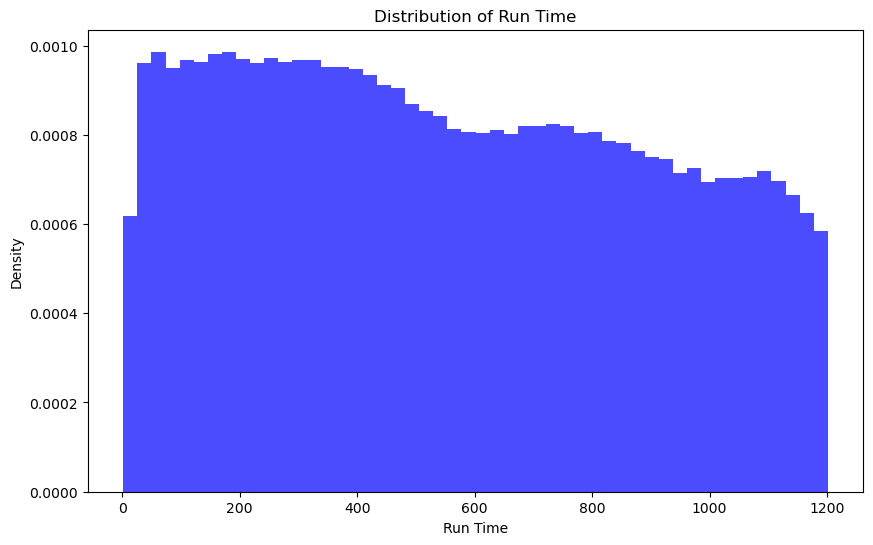

In [ ]:
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 6))
plt.hist(master_df['RunTime'], bins=50, density=True, alpha=0.7)
plt.title('Distribution of Run Time')
plt.xlabel('Run Time')
plt.ylabel('Density')
plt.show()


In [6]:
def filter_alexandrium(master_df, alpha):
    """
    Return rows where any column beginning with 'Alexandrium'
    has a value greater than alpha.
    """
    alexandrium_cols = [
        col for col in master_df.columns
        if str(col).startswith("Alexandrium")
    ]

    if not alexandrium_cols:
        raise ValueError("No Alexandrium columns found in master_df.")

    mask = (
        master_df[alexandrium_cols]
        .apply(lambda col: col > alpha)
        .any(axis=1)
    )

    return master_df.loc[mask].copy()

In [16]:
alexfilt_df = filter_alexandrium(master_df, alpha=0.9)
masterROI_df = master_df[master_df['RoiType'] != 0]
print(f"Filtered DataFrame shape: {alexfilt_df.shape}")
print(f"Master dataframe shape: {master_df.shape}")
print(f"Master ROI dataframe shape: {masterROI_df.shape}")
print(f"Master DF shape: {master_df.shape}")

Filtered DataFrame shape: (105694, 151)
Master dataframe shape: (491955, 151)
Master ROI dataframe shape: (491775, 151)
Master DF shape: (491955, 151)


Text(0.5, 1.0, 'Nauset 2024-04-29 to 2024-04-30 RunTime Distribution for Alexandrium > 0.9')

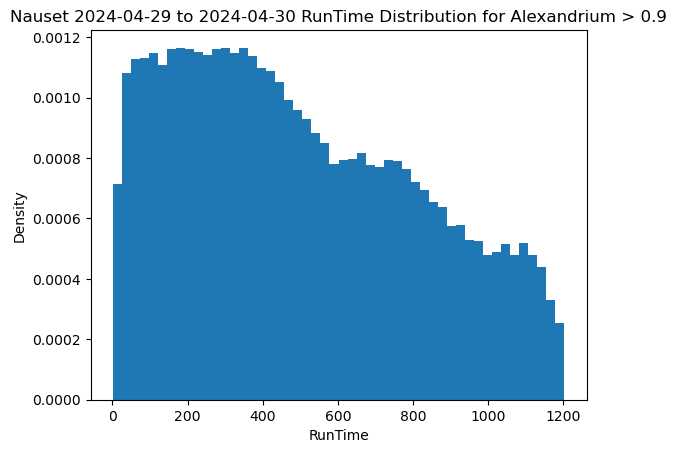

In [8]:
import matplotlib.pyplot as plt
plt.hist(alexfilt_df['RunTime'], bins=50, density=True)
plt.xlabel('RunTime')
plt.ylabel('Density')
plt.title('Nauset 2024-04-29 to 2024-04-30 RunTime Distribution for Alexandrium > 0.9')

Text(0, 0.5, 'Density')

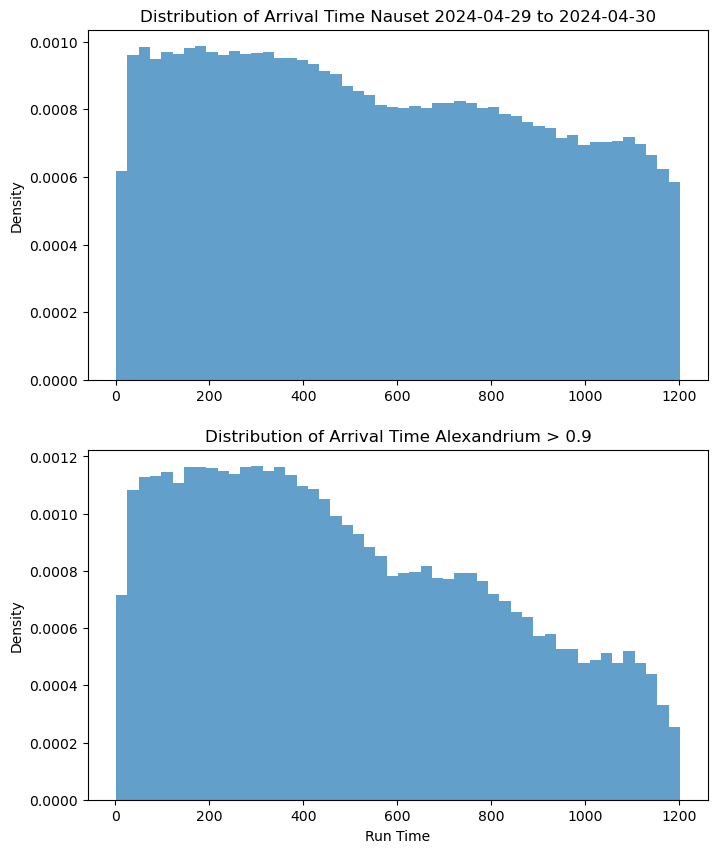

In [14]:
fig, ax = plt.subplots(2,1, figsize=(8, 10))

ax[0].hist(master_df['RunTime'], bins=50, density=True, alpha=0.7)
ax[0].set_title('Distribution of Arrival Time Nauset 2024-04-29 to 2024-04-30')
#ax[0].set_xlabel('Run Time')
ax[0].set_ylabel('Density')


ax[1].hist(alexfilt_df['RunTime'], bins=50, density=True, alpha=0.7)
ax[1].set_title('Distribution of Arrival Time Alexandrium > 0.9')
ax[1].set_xlabel('Run Time')
ax[1].set_ylabel('Density')

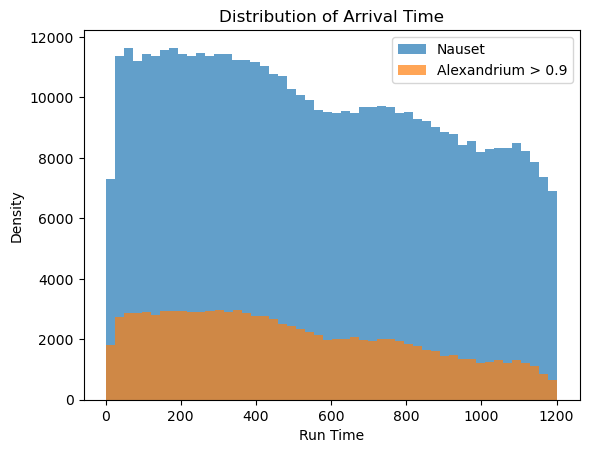

In [15]:
plt.hist(master_df['RunTime'], bins=50, alpha=0.7)
plt.hist(alexfilt_df['RunTime'], bins=50, alpha=0.7)
plt.xlabel('Run Time')
plt.ylabel('Density')
plt.title('Distribution of Arrival Time')
plt.legend(['Nauset', 'Alexandrium > 0.9'])

KS statistic: 0.13678943294454987
p-value: 0.0


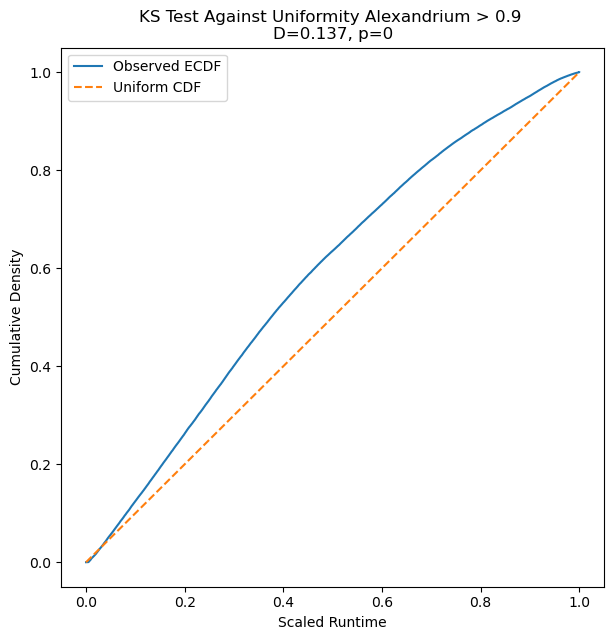

In [19]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(alexfilt_df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Alexandrium > 0.9 \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_Bivalves.png", dpi=300)

plt.show()

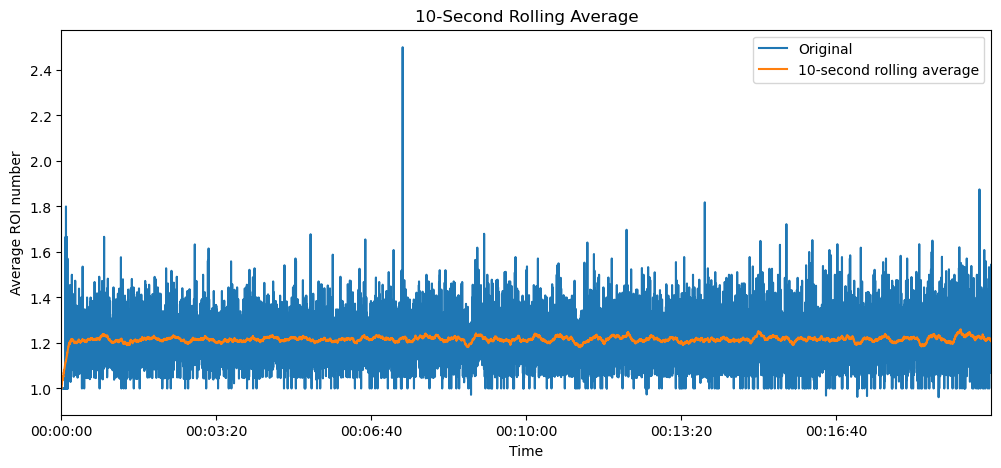

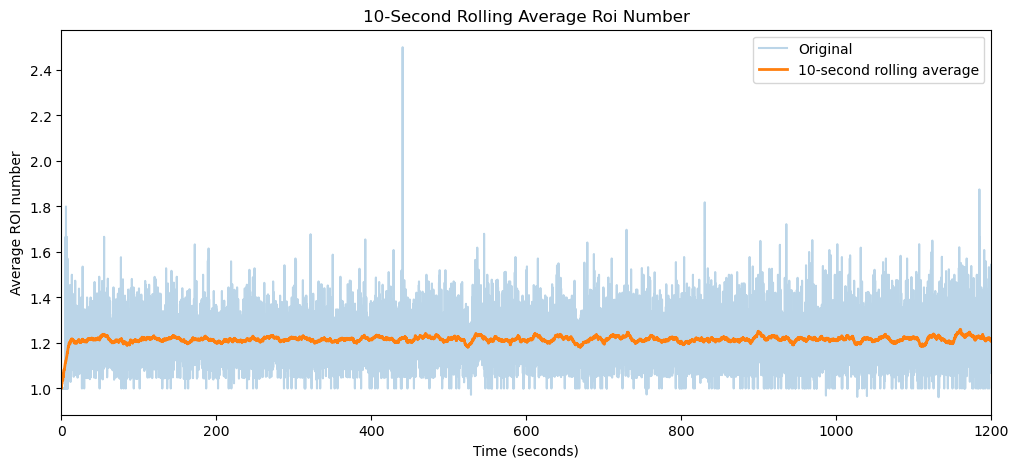

In [22]:
### Looking at ROI numbner over time 
import numpy as np
time_grid = np.linspace(0, 1200, 12001)  # 1200 time points from 0 to 1200 seconds
average_roi_number = []
for i in range(12000):
    start_time = time_grid[i]
    end_time = time_grid[i+1]
    time_df = master_df[(master_df["RunTime"] >= start_time) & (master_df["RunTime"] < end_time)]
    average_roi_number.append(time_df["RoiType"].mean())

roi_df = pd.DataFrame({
    "time": time_grid[:-1],
    "average_roi_number": average_roi_number
})

import pandas as pd
import matplotlib.pyplot as plt

plot_df = roi_df.copy()

plot_df["time"] = pd.to_timedelta(plot_df["time"], unit="s")
plot_df = plot_df.sort_values("time").set_index("time")

plot_df["rolling_avg"] = (
    plot_df["average_roi_number"]
    .rolling("10s", center=True, min_periods=1)
    .mean()
)

plot_df[["average_roi_number", "rolling_avg"]].plot(figsize=(12, 5))

plt.xlabel("Time")
plt.ylabel("Average ROI number")
plt.title("10-Second Rolling Average")
plt.legend(["Original", "10-second rolling average"])
plt.show()

x_seconds = plot_df.index.total_seconds()

plt.figure(figsize=(12, 5))
plt.plot(x_seconds, plot_df["average_roi_number"], alpha=0.3, label="Original")
plt.plot(x_seconds, plot_df["rolling_avg"], linewidth=2, label="10-second rolling average")

plt.xlim(0, 1200)
plt.xlabel("Time (seconds)")
plt.ylabel("Average ROI number")
plt.title("10-Second Rolling Average Roi Number")
plt.legend()
plt.show()

### Looking at composition of files what is in them and showing that it is mostly alexandrium 


In [23]:
class_df = pd.read_parquet("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/20240429_class_sort.parquet")

In [24]:
class_df.head()

,source_file,sample_datetime,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,...,Dinophysis_acuminata_TAG_mating,Guinardia_delicatula_TAG_external_parasite,Guinardia_delicatula_TAG_internal_parasite,Thalassiosira_TAG_chain,fiber_TAG_external_detritus,pollen_spikey_dino,best_class,best_score,collapsed_class,taxonomic_group
0,D20240429T001908_IFCB124_merged_keepzero.csv,2024-04-29T00:19:08,2,2,0.461668,6.869359,6.890796,0.071510,0.071510,0.028414,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Alexandrium_catenella,0.998047,Alexandrium*,dinoflagellate
1,D20240429T001908_IFCB124_merged_keepzero.csv,2024-04-29T00:19:08,3,3,0.539115,7.549751,7.570788,0.153045,0.081534,0.030907,...,9.536743e-06,5.960464e-08,1.788139e-07,0.000000e+00,5.364418e-07,8.344650e-07,Alexandrium_catenella,0.882812,Alexandrium*,dinoflagellate
2,D20240429T001908_IFCB124_merged_keepzero.csv,2024-04-29T00:19:08,4,4,0.661579,7.730110,7.750888,0.234753,0.081708,0.031317,...,1.788139e-07,5.960464e-08,1.192093e-07,7.152557e-07,5.960464e-08,0.000000e+00,Alexandrium_catenella,0.941406,Alexandrium*,dinoflagellate
3,D20240429T001908_IFCB124_merged_keepzero.csv,2024-04-29T00:19:08,5,5,0.631888,7.897188,7.918863,0.317190,0.082437,0.031674,...,5.960464e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Alexandrium_catenella,0.996094,Alexandrium*,dinoflagellate
4,D20240429T001908_IFCB124_merged_keepzero.csv,2024-04-29T00:19:08,6,6,0.042855,7.980219,8.002283,0.399987,0.082797,0.031676,...,5.018711e-05,5.382299e-05,2.086163e-06,7.790327e-05,1.269579e-04,2.384186e-07,Guinardia_striata,0.354248,Guinardia*,diatom


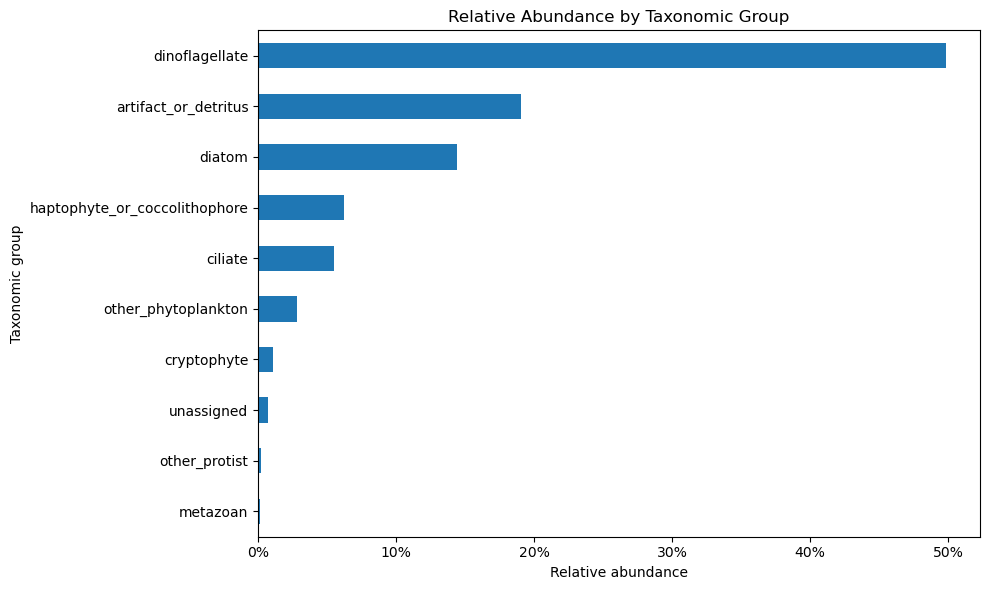

In [25]:
relative_abundance = (
    class_df["taxonomic_group"]
    .dropna()
    .value_counts(normalize=True)
    .sort_values(ascending=True)
)

ax = relative_abundance.plot(
    kind="barh",
    figsize=(10, 6)
)

ax.set_xlabel("Relative abundance")
ax.set_ylabel("Taxonomic group")
ax.set_title("Relative Abundance by Taxonomic Group")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.tight_layout()
plt.show()

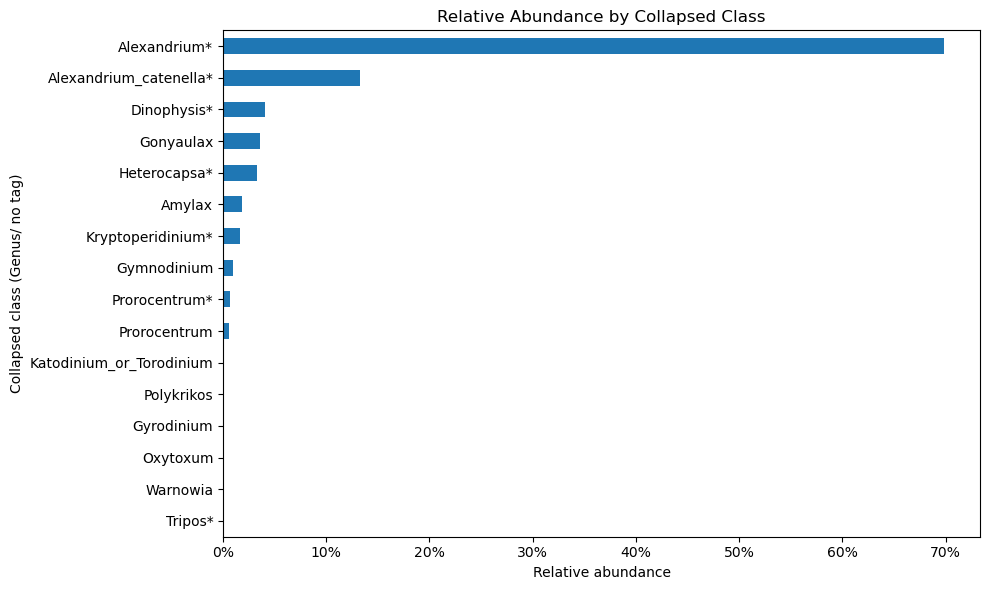

In [28]:
dinoflagellate_df = class_df[class_df["taxonomic_group"] == "dinoflagellate"]

relative_abundance = (
    dinoflagellate_df["collapsed_class"]
    .dropna()
    .value_counts(normalize=True)
    .sort_values(ascending=True)
)

ax = relative_abundance.plot(
    kind="barh",
    figsize=(10, 6)
)

ax.set_xlabel("Relative abundance")
ax.set_ylabel("Collapsed class (Genus/ no tag)")
ax.set_title("Relative Abundance by Collapsed Class")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.tight_layout()
plt.show()

In [33]:
## filter just best scores
filtered_df = class_df[class_df["best_score"] > 0.9]
## filter runtimes greater than 1200 seconds unclear where these come from but this data is messy
filtered_df = filtered_df[filtered_df["RunTime"] < 1200]

filtered_df["taxonomic_group"].value_counts()

## normalize the runtimes by total run time 

source_files = filtered_df["source_file"].unique()
for source_file in source_files:
    source_file_df = filtered_df[filtered_df["source_file"] == source_file]
    total_runtime = source_file_df["RunTime"].max()
    filtered_df.loc[filtered_df["source_file"] == source_file, "NormalizedRunTime"] = source_file_df["RunTime"] / total_runtime




filtered_df = filtered_df[
    filtered_df["taxonomic_group"].isin([
        "dinoflagellate",
        "artifact_or_detritus",
        "diatom"
    ])
]

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_75103/2302795695.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


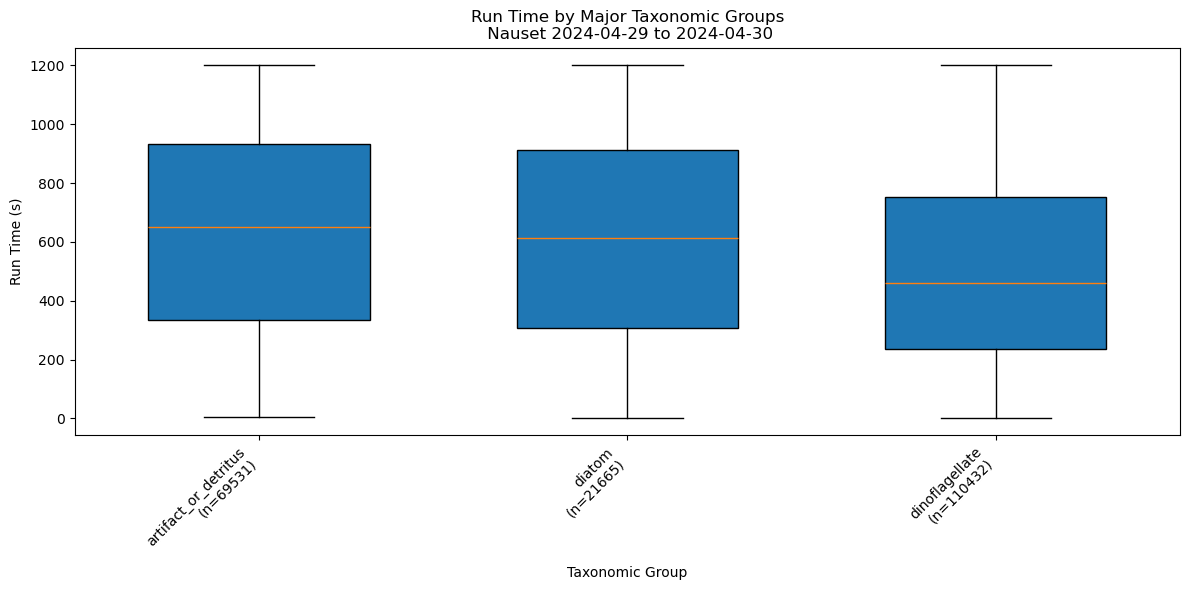

In [35]:
import matplotlib.pyplot as plt

groups = sorted(filtered_df["taxonomic_group"].dropna().unique())

data = []
labels = []

for group in groups:
    runtimes = filtered_df.loc[
        filtered_df["taxonomic_group"] == group,
        "RunTime"
    ].dropna()

    data.append(runtimes)
    labels.append(f"{group}\n(n={len(runtimes)})")

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=labels,
    widths=0.6,
    patch_artist=True
)

plt.xlabel("Taxonomic Group")
plt.ylabel("Run Time (s)")
plt.title("Run Time by Major Taxonomic Groups\n Nauset 2024-04-29 to 2024-04-30")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()